          area  order_time  order_count  delivery_time delivery_partner  \
0      Angallu          10          100             45                A   
1  Madanapalle          19          200             50                B   
2      Kurnool          12          150             20                C   
3        Kadpa          15          300             15                D   
4      Chitoor          19          250             30                E   

   customer_rating  
0                5  
1                3  
2                5  
3                2  
4                4  
Average delivery time: 32.0 mins

Peak order hours: [np.int64(15)]

Most delayed areas: ['Madanapalle']

Top rated delivery partners: ['A', 'C']



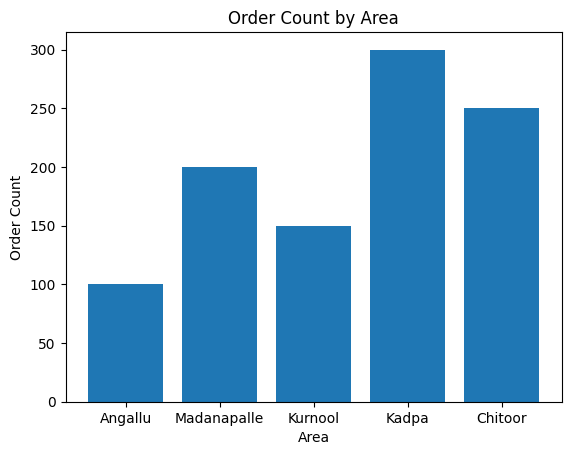

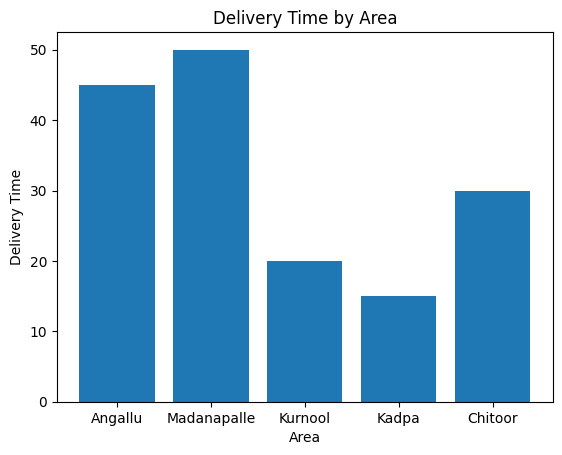

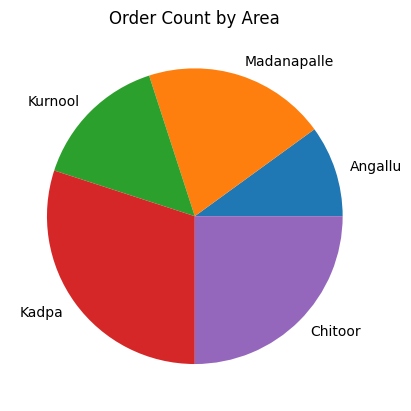

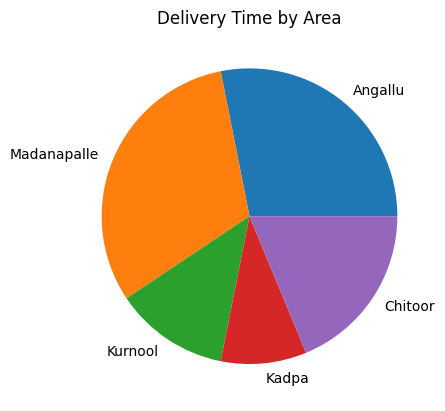

In [2]:
# swiggy/zomato food delivery analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.DataFrame({
    'area':['Angallu','Madanapalle','Kurnool','Kadpa','Chitoor'],
    'order_time':[10,19,12,15,19],#hrs
    'order_count':[100,200,150,300,250],
    'delivery_time':[45,50,20,15,30],#mins
    'delivery_partner':['A','B','C','D','E'],
    'customer_rating':[5,3,5,2,4]
})
print(df)
# Average delivery time
average_delivery_time=df['delivery_time'].mean()
print("Average delivery time:",average_delivery_time,'mins')
print()
# peakorderhours
peakorderhours=[]
ordercount=df['order_count']
ordertime=df['order_time']
for i in range(len(ordercount)):
    if ordercount[i]==max(ordercount):
        peakorderhours.append(ordertime[i])
print("Peak order hours:",peakorderhours)
print()
# most_delayed_areas
mostdelayedareas=[]
deliverytime=df['delivery_time']
for i in range(len(deliverytime)):
    if deliverytime[i]==max(deliverytime):
        mostdelayedareas.append(df['area'][i])
print("Most delayed areas:",mostdelayedareas)
print()
# top_rated_delivery_partners
toprateddeliverypartners=[]
customerrating=df['customer_rating']
for i in range(len(customerrating)):
    if customerrating[i]==max(customerrating):
        toprateddeliverypartners.append(df['delivery_partner'][i])
print("Top rated delivery partners:",toprateddeliverypartners)
print()
# visuvals
# Barplot
plt.bar(df['area'],df['order_count'])
plt.xlabel('Area')
plt.ylabel('Order Count')
plt.title('Order Count by Area')
plt.show()
print()
plt.bar(df['area'],df['delivery_time'])
plt.xlabel('Area')
plt.ylabel('Delivery Time')
plt.title('Delivery Time by Area')
plt.show()
print()
# Pie Chart
plt.pie(df['order_count'],labels=df['area'])
plt.title('Order Count by Area')
plt.show()
print()
plt.pie(df['delivery_time'],labels=df['area'])
plt.title('Delivery Time by Area')
plt.show()
print()

## Bank Fraud Detection Analysis

Let's continue with the bank transaction data and implement some basic fraud detection techniques.

  productpurchases cartabandonment  customerrating paymentmethods  sales  \
0            phone           shoes               2           cash    100   
1             book          shirts               4            upi    200   
2          perfume           pouch               3     creditcard     50   
3             food             toy               5       upi lite     85   

   revenue     customer  
0     1000        sunil  
1     2000        gokul  
2      500          sai  
3      850  lashmikanth  
most_sold_products :  book

High_revenue_customer :  gokul

Most_used_paymentmethod :  upi

Product_with_poor_ratings :  phone



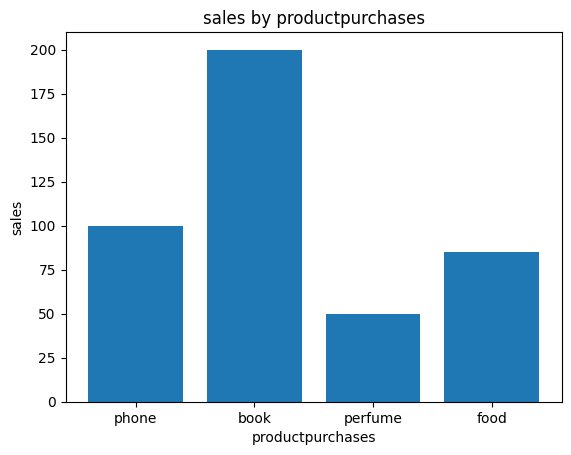

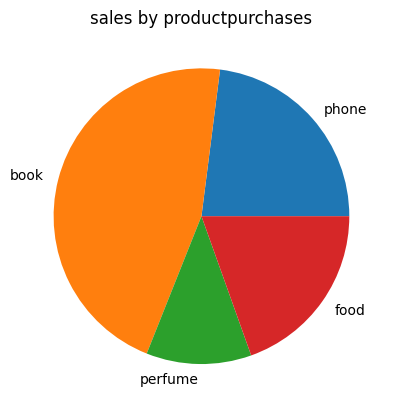

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.DataFrame({
'productpurchases':['phone','book','perfume','food'],
'cartabandonment':['shoes','shirts','pouch','toy'],
'customerrating':[2,4,3,5],
'paymentmethods':['cash','upi','creditcard','upi lite'],
'sales':[100,200,50,85],
'revenue':[1000,2000,500,850],
'customer':['sunil','gokul','sai','lashmikanth']

})
print(df)
# most_sold_products
most_sold_products=[]
most_sold_products=df['productpurchases'][df['sales'].idxmax()]
print("most_sold_products : ",most_sold_products)
print()
# High_revenue_customer
High_revenue_customer=[]
High_revenue_customer=df['customer'][df['revenue'].idxmax()]
print("High_revenue_customer : ",High_revenue_customer)
print()
# Most_used_paymentmethod
Most_used_paymentmethod=[]
Most_used_paymentmethod=df['paymentmethods'][df['sales'].idxmax()]
print("Most_used_paymentmethod : ",Most_used_paymentmethod)
print()
# Product_with_poor_ratings
Product_with_poor_ratings=[]
Product_with_poor_ratings=df['productpurchases'][df['customerrating'].idxmin()]
print("Product_with_poor_ratings : ",Product_with_poor_ratings)
print()
# Visuals
#Bar chart
plt.bar(df['productpurchases'],df['sales'])
plt.xlabel('productpurchases')
plt.ylabel('sales')
plt.title('sales by productpurchases')
plt.show()
print()
# Pie chart
plt.pie(df['sales'],labels=df['productpurchases'])
plt.title('sales by productpurchases')
plt.show()
print()

Transaction Data
   transaction_id    amount   location  hour  login_attempts fraud
0             101   5000.00      Delhi    14               2    No
1             102    250.75     Mumbai     2               8   Yes
2             103  12000.00    Chennai    23              12   Yes
3             104    999.99  Hyderabad    11               3    No
4             105   7000.00  Bangalore     1              15   Yes

Unusual Transactions
   transaction_id  amount   location  hour  login_attempts fraud
1             102  250.75     Mumbai     2               8   Yes
3             104  999.99  Hyderabad    11               3    No

High Risk Transactions
   transaction_id   amount   location  hour  login_attempts fraud
2             103  12000.0    Chennai    23              12   Yes
4             105   7000.0  Bangalore     1              15   Yes

Fraud Analysis
Average Fraud Amount: 6416.916666666667
Average Login Attempts: 11.666666666666666

Fraud Transaction Hours
1     2
2    23
4 

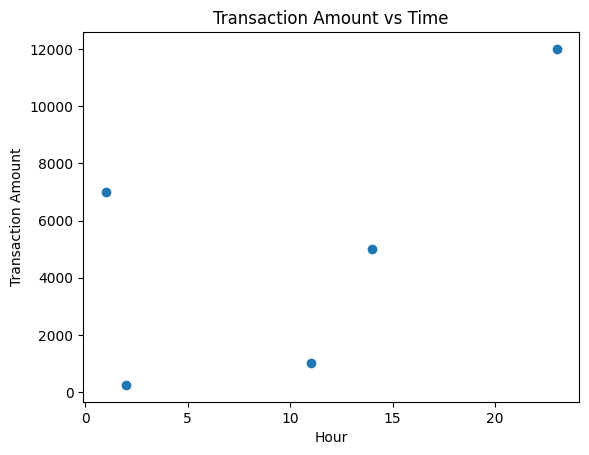

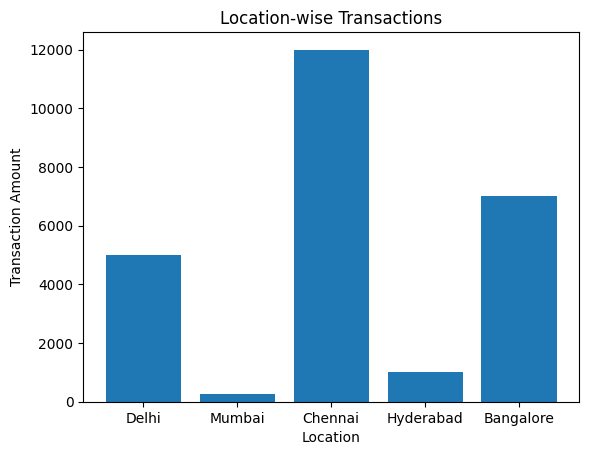

In [16]:
# Bank Fraud Detection Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sample dataset
df = pd.DataFrame({
    'transaction_id': [101, 102, 103, 104, 105],
    'amount': [5000, 250.75, 12000, 999.99, 7000],
    'location': ['Delhi', 'Mumbai', 'Chennai', 'Hyderabad', 'Bangalore'],
    'hour': [14, 2, 23, 11, 1],
    'login_attempts': [2, 8, 12, 3, 15],
    'fraud': ['No', 'Yes', 'Yes', 'No', 'Yes']
})

print("Transaction Data")
print(df)

# Unusual transactions (decimal amounts)
unusual = df[df['amount'] % 1 != 0]

print("\nUnusual Transactions")
print(unusual)

# High-risk transactions
high_risk = df[(df['amount'] > 5000) & (df['login_attempts'] > 5)]

print("\nHigh Risk Transactions")
print(high_risk)

# Fraud cases analysis
fraud_cases = df[df['fraud'] == 'Yes']

print("\nFraud Analysis")
print("Average Fraud Amount:", fraud_cases['amount'].mean())
print("Average Login Attempts:", fraud_cases['login_attempts'].mean())

print("\nFraud Transaction Hours")
print(fraud_cases['hour'])

# Scatter Plot
plt.scatter(df['hour'], df['amount'])
plt.xlabel('Hour')
plt.ylabel('Transaction Amount')
plt.title('Transaction Amount vs Time')
plt.show()

# Bar Chart
plt.bar(df['location'], df['amount'])
plt.xlabel('Location')
plt.ylabel('Transaction Amount')
plt.title('Location-wise Transactions')
plt.show()

Product Data:
  Product  DailySales  ProductStock SeasonalDemand
0      P1         120            50           High
1      P2          15           200            Low
2      P3          80            40           High
3      P4          10           150            Low
4      P5          60            70         Medium

5

Updated Data:
  Product  DailySales  ProductStock SeasonalDemand          Status
0      P1         120            50           High  Restock Needed
1      P2          15           200            Low     Overstocked
2      P3          80            40           High  Restock Needed
3      P4          10           150            Low     Overstocked
4      P5          60            70         Medium  Balanced Stock

Fast Moving Products:

Slow Moving Products:

out of stock trends
No product is out of stock



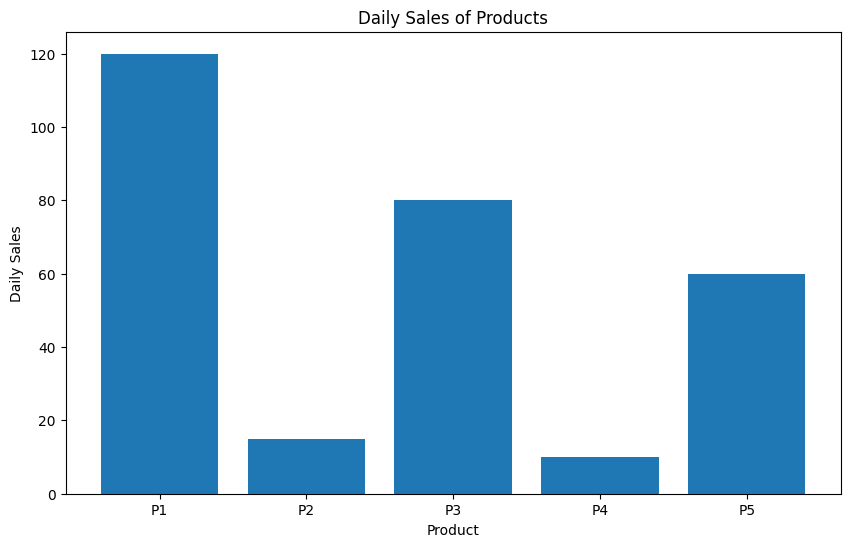

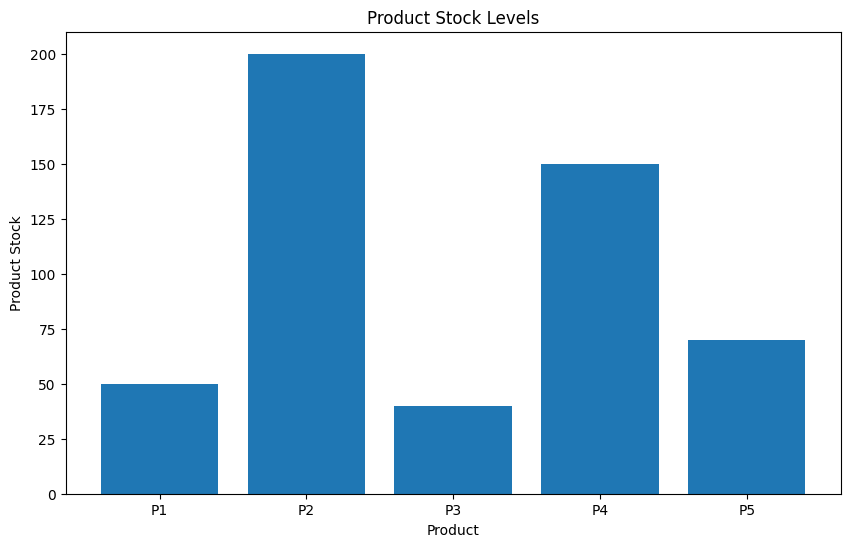

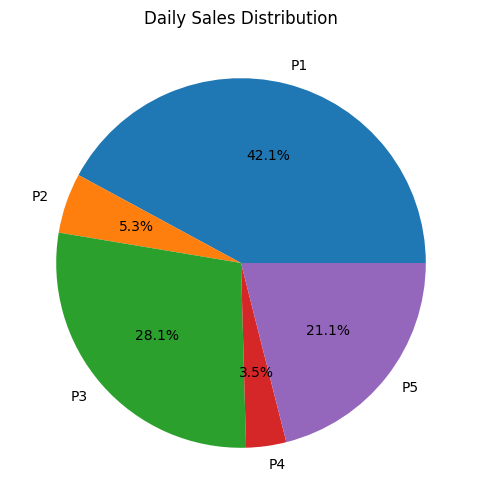

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


data = {
    'Product': ['P1', 'P2', 'P3', 'P4', 'P5'],
    'DailySales': [120, 15, 80, 10, 60],
    'ProductStock': [50, 200, 40, 150, 70],
    'SeasonalDemand': ['High', 'Low', 'High', 'Low', 'Medium']
}

df = pd.DataFrame(data)

print("Product Data:")
print(df)
print()
print(len(df))

status = []

for i in range(len(df)):

    if (df['DailySales'][i] > 70 and
        df['ProductStock'][i] < 60):
        status.append("Restock Needed")

    elif (df['DailySales'][i] < 20 and
          df['ProductStock'][i] > 100):
        status.append("Overstocked")

    else:
        status.append("Balanced Stock")

df['Status'] = status

print("\nUpdated Data:")
print(df)

print("\nFast Moving Products:")
for i in range(len(df)):
    if df['Status'][i] == "Fast Moving":
        print(df['Product'][i])

print("\nSlow Moving Products:")
for i in range(len(df)):
    if df['Status'][i] == "Slow Moving":
        print(df['Product'][i])
print("\nout of stock trends")
for i in range(len(df)):
  if df['ProductStock'][i] == 0:
    print(f"{df['Product'][i]} is out of stock")
print("No product is out of stock")
print()

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(df['Product'], df['DailySales'])
plt.xlabel('Product')
plt.ylabel('Daily Sales')
plt.title('Daily Sales of Products')
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(df['Product'], df['ProductStock'])
plt.xlabel('Product')
plt.ylabel('Product Stock')
plt.title('Product Stock Levels')
plt.show()

plt.figure(figsize=(10, 6))
plt.pie(df['DailySales'], labels=df['Product'], autopct='%1.1f%%')
plt.title('Daily Sales Distribution')
plt.show()